#Sentiment Analysis using NLTK: 
[GitRepo](https://github.com/uDivy/sentiment_aviz_stock_news_python/tree/development)

# Prebuilt Flair Model

In [1]:
!python -m pip install flair

  Using cached importlib_metadata-3.10.1-py3-none-any.whl (14 kB)
  Attempting uninstall: importlib-metadata
    Found existing installation: importlib-metadata 4.11.4
    Uninstalling importlib-metadata-4.11.4:
      Successfully uninstalled importlib-metadata-4.11.4


ERROR: After October 2020 you may experience errors when installing or updating packages. This is because pip will change the way that it resolves dependency conflicts.

We recommend you use --use-feature=2020-resolver to test your packages with the new resolver before it becomes the default.

markdown 3.3.7 requires importlib-metadata>=4.4; python_version < "3.10", but you'll have importlib-metadata 3.10.1 which is incompatible.
konoha 4.6.5 requires requests<3.0.0,>=2.25.1, but you'll have requests 2.24.0 which is incompatible.


1. Define Model
2. Tokenize your input text
3. Pass the tokenized input to the model
4. Slice the output

In [2]:
!python -m pip install --user --upgrade numpy

  Using cached numpy-1.22.4-cp38-cp38-win_amd64.whl (14.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.19.5
    Uninstalling numpy-1.19.5:
      Successfully uninstalled numpy-1.19.5


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an EnvironmentError: [WinError 5] Access is denied: 'C:\\Users\\upadh\\AppData\\Roaming\\Python\\Python38\\site-packages\\~-mpy\\.libs\\libopenblas.WCDJNK7YVMPZQ2ME2ZZHJJRJ3JIKNDB7.gfortran-win_amd64.dll'
Check the permissions.



In [3]:
import flair
model = flair.models.TextClassifier.load('en-sentiment')

2022-05-27 18:53:04,090 loading file C:\Users\upadh\.flair\models\sentiment-en-mix-distillbert_4.pt


In [4]:
text = "I like you!"  # we are expecting a confidently positive sentiment here

sentence = flair.data.Sentence(text)

sentence

Sentence: "I like you !"   [− Tokens: 4]

In [5]:
model.predict(sentence)

In [6]:
sentence.get_labels()[0].score

0.9928143620491028

In [7]:
sentence.get_labels()[0].value

'POSITIVE'

# Sentiment Models with Transformers

In [8]:
from transformers import BertForSequenceClassification, BertTokenizer

# initialize the tokenizer for BERT models
tokenizer = BertTokenizer.from_pretrained('ProsusAI/finbert')
# initialize the model for sequence classification
model = BertForSequenceClassification.from_pretrained('ProsusAI/finbert')

In [9]:
# this is our example text
txt = ("Given the recent downturn in stocks especially in tech which is likely to persist as yields keep going up, "
       "I thought it would be prudent to share the risks of investing in ARK ETFs, written up very nicely by "
       "[The Bear Cave](https://thebearcave.substack.com/p/special-edition-will-ark-invest-blow). The risks comes "
       "primarily from ARK's illiquid and very large holdings in small cap companies. ARK is forced to sell its "
       "holdings whenever its liquid ETF gets hit with outflows as is especially the case in market downturns. "
       "This could force very painful liquidations at unfavorable prices and the ensuing crash goes into a "
       "positive feedback loop leading into a death spiral enticing even more outflows and predatory shorts.")

tokens = tokenizer.encode_plus(txt, max_length=512, truncation=True, padding='max_length',
                               add_special_tokens=True, return_tensors='pt')

tokens

{'input_ids': tensor([[  101,  2445,  1996,  3522,  2091, 22299,  1999, 15768,  2926,  1999,
          6627,  2029,  2003,  3497,  2000, 29486,  2004, 16189,  2562,  2183,
          2039,  1010,  1045,  2245,  2009,  2052,  2022, 10975, 12672,  3372,
          2000,  3745,  1996, 10831,  1997, 19920,  1999, 15745,  3802, 10343,
          1010,  2517,  2039,  2200, 19957,  2011,  1031,  1996,  4562,  5430,
          1033,  1006, 16770,  1024,  1013,  1013,  1996,  4783,  2906, 27454,
          1012,  4942,  9153,  3600,  1012,  4012,  1013,  1052,  1013,  2569,
          1011,  3179,  1011,  2097,  1011, 15745,  1011, 15697,  1011,  6271,
          1007,  1012,  1996, 10831,  3310,  3952,  2013, 15745,  1005,  1055,
          5665, 18515, 21272,  1998,  2200,  2312,  9583,  1999,  2235,  6178,
          3316,  1012, 15745,  2003,  3140,  2000,  5271,  2049,  9583,  7188,
          2049,  6381,  3802,  2546,  4152,  2718,  2007,  2041, 12314,  2015,
          2004,  2003,  2926,  1996,  

In [10]:
output = model(**tokens)

output

SequenceClassifierOutput(loss=None, logits=tensor([[-1.8200,  2.4484,  0.0216]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

In [11]:
# Now conver the output tensor to probabilities with softmax function
import torch.nn.functional as F

# apply softmax to the logits output tensor of our model (in index 0) across dimension -1
probs = F.softmax(output[0], dim=-1) # dimension of 3D[0, 1, 2] -1 is 2 (last)

probs

tensor([[0.0127, 0.9072, 0.0801]], grad_fn=<SoftmaxBackward0>)

In [12]:
import torch

pred = torch.argmax(probs)

pred

tensor(1)

In [13]:
pred.item()

1

# Sentiment Model with TensorFlow and Transformers

## Data Preprocessing 

In [14]:
# load data from Kaggle
!python -m pip install kaggle

In [15]:
import kaggle # dowload api token from your account 

In [16]:
from kaggle.api.kaggle_api_extended import KaggleApi
import zipfile
import os

api = KaggleApi()
api.authenticate()

In [1]:
datastore_SMTF = 'D:/2022/My/STUDY/NLP_Udemy_JamesBriggs/Resources/datastore/SentModelTF/'

In [18]:
for file in ['train.tsv', 'test.tsv']:
    api.competition_download_file('sentiment-analysis-on-movie-reviews', f'{file}.zip', path=datastore_SMTF)

    with zipfile.ZipFile(f'{datastore_SMTF}{file}.zip', 'r') as zip_ref:
        zip_ref.extractall(datastore_SMTF)

    os.remove(f'{datastore_SMTF}{file}.zip')

  0%|                                                                                                                                          | 0.00/1.28M [00:00<?, ?B/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.28M/1.28M [00:00<00:00, 5.11MB/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 494k/494k [00:00<00:00, 12.1MB/s]

In [19]:
import pandas as pd

df = pd.read_csv(datastore_SMTF+'train.tsv', sep='\t')
df.head()

,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


<AxesSubplot:>

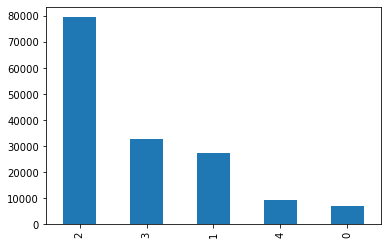

In [20]:
df['Sentiment'].value_counts().plot(kind='bar')

In [21]:
# We will be tokenizing this text to create two input tensors; our input IDs, and attention mask.
import numpy as np

seq_len = 512
num_samples = len(df)

num_samples, seq_len

(156060, 512)

## Tokenization

In [22]:
from transformers import BertTokenizer

# initialize tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

# tokenize - this time returning Numpy tensors
tokens = tokenizer(df['Phrase'].tolist(), max_length=seq_len, truncation=True,
                   padding='max_length', add_special_tokens=True,
                   return_tensors='np')

In [23]:
tokens.keys()

dict_keys(['input_ids', 'token_type_ids', 'attention_mask'])

In [24]:
tokens['input_ids'][:10]

array([[  101,   138,  1326, ...,     0,     0,     0],
       [  101,   138,  1326, ...,     0,     0,     0],
       [  101,   138,  1326, ...,     0,     0,     0],
       ...,
       [  101, 13936, 25265, ...,     0,     0,     0],
       [  101, 13936, 25265, ...,     0,     0,     0],
       [  101, 15107,  1103, ...,     0,     0,     0]])

In [25]:
tokens['attention_mask'][:10] # to take only phrase into account not the padding

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]])

In [26]:
# And now we save them to file as Numpy binary files:
with open(datastore_SMTF+'movie-xids.npy', 'wb') as f:
    np.save(f, tokens['input_ids'])
with open(datastore_SMTF+'movie-xmask.npy', 'wb') as f:
    np.save(f, tokens['attention_mask'])

In [27]:
# Now that we have them on file, we can delete the in-memory arrays to free up memory.
del tokens

In [28]:
# to train the model we also need the labels

# first extract sentiment column
arr = df['Sentiment'].values

# we then initialize the zero array 
labels = np.zeros((num_samples, arr.max()+1))
labels.shape

(156060, 5)

In [29]:
# One-Hot Encoding

labels[np.arange(num_samples), arr] = 1

labels

array([[0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       ...,
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.]])

In [30]:
with open(datastore_SMTF+'movie-labels.npy', 'wb') as f:
    np.save(f, labels)

## Tensorflow input pipeline

In [31]:
import numpy as np

with open(datastore_SMTF+'movie-xids.npy', 'rb') as f:
    Xids = np.load(f, allow_pickle=True)
with open(datastore_SMTF+'movie-xmask.npy', 'rb') as f:
    Xmask = np.load(f, allow_pickle=True)
with open(datastore_SMTF+'movie-labels.npy', 'rb') as f:
    labels = np.load(f, allow_pickle=True)

In [32]:
!python -m pip install --user --upgrade tensorflow==2.5

Requirement already up-to-date: tensorflow==2.5 in c:\users\upadh\appdata\roaming\python\python38\site-packages (2.5.0)
  Using cached numpy-1.19.5-cp38-cp38-win_amd64.whl (13.3 MB)
  Using cached importlib_metadata-4.11.4-py3-none-any.whl (18 kB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.22.4
    Uninstalling numpy-1.22.4:
      Successfully uninstalled numpy-1.22.4


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an EnvironmentError: [WinError 5] Access is denied: 'C:\\Users\\upadh\\AppData\\Roaming\\Python\\Python38\\site-packages\\~~mpy\\.libs\\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll'
Check the permissions.



In [33]:
import tensorflow as tf

print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [34]:
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
  details = tf.config.experimental.get_device_details(gpu_devices[0])
  details.get('device_name', 'Unknown GPU')
  print(details)
else:
    print("What!!!!")

{'device_name': 'NVIDIA GeForce MX130', 'compute_capability': (5, 0)}


In [44]:
# if len(gpu_devices) > 0:
#     tf.config.experimental.set_memory_growth(gpu_devices[0], True)
# print(tf.config.experimental.get_memory_growth(gpu_devices[0]))

In [36]:
# We can take these three arrays and create a TF dataset object with them using from_tensor_slices
dataset = tf.data.Dataset.from_tensor_slices((Xids, Xmask, labels))

dataset.take(1)

<TakeDataset shapes: ((512,), (512,), (5,)), types: (tf.int32, tf.int32, tf.float64)>

In [37]:
'''
we want the input and output of type: 
({
    'input_ids': <input_id_tensor>,
    'attention_mask': <mask_tensor>
}
output)
'''

"\nwe want the input and output of type: \n({\n    'input_ids': <input_id_tensor>,\n    'attention_mask': <mask_tensor>\n}\noutput)\n"

In [38]:
def map_func(input_ids, masks, labels):
    # we convert our three-item tuple into a two-item tuple where the input item is a dictionary
    return {'input_ids': input_ids, 'attention_mask': masks}, labels

# then we use the dataset map method to apply this transformation
dataset = dataset.map(map_func)

dataset.take(1)

<TakeDataset shapes: ({input_ids: (512,), attention_mask: (512,)}, (5,)), types: ({input_ids: tf.int32, attention_mask: tf.int32}, tf.float64)>

In [39]:
# creating batch to train the model
batch_size = 4

dataset = dataset.shuffle(10000).batch(batch_size, drop_remainder=True)

dataset.take(1)

<TakeDataset shapes: ({input_ids: (4, 512), attention_mask: (4, 512)}, (4, 5)), types: ({input_ids: tf.int32, attention_mask: tf.int32}, tf.float64)>

In [40]:
# creating train-test split for the training
split = 0.9

# we need to calculate how many batches must be taken to create 90% training set
size = int((Xids.shape[0] / batch_size) * split)

size

35113

In [41]:
train_ds = dataset.take(size)
val_ds = dataset.skip(size)

# free up memory
del dataset

In [42]:
tf.data.experimental.save(train_ds,datastore_SMTF+'train')
tf.data.experimental.save(val_ds,datastore_SMTF+'val')

In [45]:
'''
In the next notebook we will be loading these files using tf.data.experimental.load. 
Which requires us to define the tensor element_spec - which describes the tensor shape. 
To find our dataset element spec we can write:
'''

'\nIn the next notebook we will be loading these files using tf.data.experimental.load. \nWhich requires us to define the tensor element_spec - which describes the tensor shape. \nTo find our dataset element spec we can write:\n'

In [46]:
train_ds.element_spec

({'input_ids': TensorSpec(shape=(4, 512), dtype=tf.int32, name=None),
  'attention_mask': TensorSpec(shape=(4, 512), dtype=tf.int32, name=None)},
 TensorSpec(shape=(4, 5), dtype=tf.float64, name=None))

In [47]:
val_ds.element_spec == train_ds.element_spec

True

In [48]:
ds = tf.data.experimental.load(datastore_SMTF+'train', element_spec=train_ds.element_spec)

## Build and Train the model

In [49]:
from transformers import TFAutoModel

bert = TFAutoModel.from_pretrained('bert-base-cased')

# we can view the model using the summary method
bert.summary()

Some layers from the model checkpoint at bert-base-cased were not used when initializing TFBertModel: ['mlm___cls', 'nsp___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertModel were initialized from the model checkpoint at bert-base-cased.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


Model: "tf_bert_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
bert (TFBertMainLayer)       multiple                  108310272 
Total params: 108,310,272
Trainable params: 108,310,272
Non-trainable params: 0
_________________________________________________________________


In [50]:
'''
Now we need to define the frame around Bert, we need:

Two input layers (one for input IDs and one for attention mask).

A post-bert dropout layer to reduce the likelihood of overfitting and improve generalization.

Max pooling layer to convert the 3D tensors output by Bert to 2D.

Final output activations using softmax for outputting categorical probabilities.
'''

'\nNow we need to define the frame around Bert, we need:\n\nTwo input layers (one for input IDs and one for attention mask).\n\nA post-bert dropout layer to reduce the likelihood of overfitting and improve generalization.\n\nMax pooling layer to convert the 3D tensors output by Bert to 2D.\n\nFinal output activations using softmax for outputting categorical probabilities.\n'

In [51]:
# import tensorflow as tf

# two input layers, we ensure layer name variables match to dictionary keys in TF dataset
input_ids = tf.keras.layers.Input(shape=(512,), name='input_ids', dtype='int32')
mask = tf.keras.layers.Input(shape=(512,), name='attention_mask', dtype='int32')

# we access the transformer model within our bert object using the bert attribute (eg bert.bert instead of bert)
embeddings = bert.bert(input_ids, attention_mask=mask)[1]  # access final activations (alread max-pooled) [1]
# convert bert embeddings into 5 output classes
x = tf.keras.layers.Dense(128, activation='relu')(embeddings)
y = tf.keras.layers.Dense(5, activation='softmax', name='outputs')(x)

Instructions for updating:
The `validate_indices` argument has no effect. Indices are always validated on CPU and never validated on GPU.


In [52]:
   # initialize model
model = tf.keras.Model(inputs=[input_ids, mask], outputs=y)

#freeze bert layer
model.layers[2].trainable = False # No Weight Changes

# print out model summary
model.summary() # so basically: layer0(i/p)=>layer1(Mask)=>layer2(BertWillGenerateEmbeddings)=>layer3(dense:1024)=>layer4(dense:5,o/p)

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_ids (InputLayer)          [(None, 512)]        0                                            
__________________________________________________________________________________________________
attention_mask (InputLayer)     [(None, 512)]        0                                            
__________________________________________________________________________________________________
bert (TFBertMainLayer)          TFBaseModelOutputWit 108310272   input_ids[0][0]                  
                                                                 attention_mask[0][0]             
__________________________________________________________________________________________________
dense (Dense)                   (None, 128)          98432       bert[0][1]                   

In [53]:
# Our model architecture is now setup, and we can initialize our training parameters(the weights) like so:

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5, decay=1e-6)
loss = tf.keras.losses.CategoricalCrossentropy() # as we have 5 classes
acc = tf.keras.metrics.CategoricalAccuracy('accuracy')

model.compile(optimizer=optimizer, loss=loss, metrics=[acc])

In [54]:
# Architecture and Training Parameeter is set, now we have to train the model
# Now all we need to do is train our model. 
# For this, we need to load in our training and validation datasets - 
# which also requires our dataset element specs to be defined.
element_spec = ({'input_ids': tf.TensorSpec(shape=(batch_size, 512), dtype=tf.int32, name=None),
                 'attention_mask': tf.TensorSpec(shape=(batch_size, 512), dtype=tf.int32, name=None)},
                tf.TensorSpec(shape=(batch_size, 5), dtype=tf.float64, name=None))

# load the training and validation sets
train_ds = tf.data.experimental.load(datastore_SMTF+'train', element_spec=element_spec)
val_ds = tf.data.experimental.load(datastore_SMTF+'val', element_spec=element_spec)

# view the input format
train_ds.take(1)

<TakeDataset shapes: ({input_ids: (4, 512), attention_mask: (4, 512)}, (4, 5)), types: ({input_ids: tf.int32, attention_mask: tf.int32}, tf.float64)>

In [55]:
!python -m pip show tensorflow

Name: tensorflow
Version: 2.5.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: c:\users\upadh\appdata\roaming\python\python38\site-packages
Requires: termcolor, tensorboard, opt-einsum, wheel, numpy, typing-extensions, flatbuffers, keras-preprocessing, tensorflow-estimator, protobuf, absl-py, gast, google-pasta, six, astunparse, wrapt, h5py, grpcio, keras-nightly
Required-by: 


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

Epoch 1/3
 2097/35113 [>.............................] - ETA: 34:10:00 - loss: 1.2009 - accuracy: 0.5573

In [ ]:
model.save('sentiment_model')

# Loading and Predictions

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model('sentiment_model')

# view model architecture to confirm we have save and loaded correctly
model.summary()

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

def prep_data(text):
    tokens = tokenizer.encode_plus(text, max_length=512,
                                   truncation=True, padding='max_length',
                                   add_special_tokens=True, return_token_type_ids=False,
                                   return_tensors='tf')
    # tokenizer returns int32 tensors, we need to return float64, so we use tf.cast
    return {'input_ids': tf.cast(tokens['input_ids'], tf.float64),
            'attention_mask': tf.cast(tokens['attention_mask'], tf.float64)}

In [ ]:
probs = model.predict(prep_data("hello world"))[0]

probs

In [ ]:
import numpy as np

np.argmax(probs)

In [ ]:
#So we have made a test prediction, but we want to be applying this to real phrases from test.tsv. 
#We will load the data into a dataframe, remove fragment duplicates based on SentenceId, 
#then iterate through the list and create a new sentiment column.
import pandas as pd

# so we can see full phrase
pd.set_option('display.max_colwidth', None)

df = pd.read_csv(datastore_SMTF+'test.tsv', sep='\t')
df.head()


In [ ]:
df = df.drop_duplicates(subset=['SentenceId'], keep='first')
df.head()

In [ ]:
df['Sentiment'] = None

for i, row in df.iterrows():
    # get token tensors
    tokens = prep_data(row['Phrase'])
    # get probabilities
    probs = model.predict(tokens)
    # find argmax for winning class
    pred = np.argmax(probs)
    # add to dataframe
    df.at[i, 'Sentiment'] = pred

df.head()

In [ ]:
df.tail()